In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle
from scipy.signal import fftconvolve
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter, label, find_objects
from scipy.ndimage import shift
from scipy.ndimage import zoom
from skimage.registration import phase_cross_correlation

def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]
from scipy.ndimage import shift as nd_shift

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")


from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase
import logging
logging.getLogger("hyperspy").setLevel(logging.ERROR)
def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba

from abtem.core.energy import energy2sigma

def subpixel_shift(img, shift):
    """
    Circularly shift a 2D (or 3D with leading singleton) array by a
    sub-pixel amount using the Fourier shift theorem.
    shift: (dy, dx) in pixels, applied along the last two axes.
    Positive dx shifts content to the right (same convention as np.roll).
    """
    dy, dx = shift
    *_, ny, nx = img.shape
    
    F = np.fft.fft2(img, axes=(-2, -1))
    
    ky = np.fft.fftfreq(ny)[:, None]
    kx = np.fft.fftfreq(nx)[None, :]
    
    phase_ramp = np.exp(-2j * np.pi * (ky * dy + kx * dx))
    
    F_shifted = F * phase_ramp
    shifted = np.fft.ifft2(F_shifted, axes=(-2, -1))
    
    # if the input was real, the output should be too (up to numerical noise)
    if np.isrealobj(img):
        shifted = shifted.real
    
    return shifted

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

def compute_global_shift_xcorr(img_ref, img_target, upsample_factor=20):
    """
    Compute the global (row_shift, col_shift) i.e. (dy, dx) that best
    aligns img_target to img_ref, using Fourier-based phase cross-correlation.

    Parameters
    ----------
    img_ref : reference image (e.g. gt_image)
    img_target : image to register against the reference (e.g. phase)
    upsample_factor : controls sub-pixel precision (20 -> 1/20 px precision)

    Returns
    -------
    shift : (dy, dx) — apply as target_shifted = shift(img_target, shift) to align it to img_ref
    error : normalized RMS registration error
    diffphase : global phase difference (usually irrelevant here)
    """
    shift, error, diffphase = phase_cross_correlation(
        img_ref, img_target, upsample_factor=upsample_factor, normalization='phase'
    )
    return shift, error, diffphase

quantEM version: 0.1.8


In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
convergence_angle = 12
gpts = 64
force_com_rotation = 0
batch_size = 8
device = "cuda:1"
num_iters = 30
reset = True
d = 10
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = False


# -----------------------------
# Load upper/lower CSVs
# -----------------------------
dfs = []

for particle in ["first", "second", "always"]:
    results_dir = f"results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"

    csv_path = os.path.join(
        results_dir,
        f"shifts_conv{convergence_angle}"
        f"_batchsize{batch_size}"
        f"_iters{num_iters}"
        f"_gpts{gpts}_{particle}.csv"
    )
    df = pd.read_csv(csv_path)

    # csv_path = f'results_conv28_batchsize512_iters125_gpts128_2particles_d20_dose1.0e+15_large_fov2/shifts_conv28_batchsize512_iters125_gpts128_{particle}.csv'
    # csv_path = f'results_conv22_batchsize8_iters30_gpts128_2particles_d20_dose1.0e+07_large_fov2/shifts_conv22_batchsize8_iters30_gpts128_{particle}.csv'
    # csv_path = f'results_conv14_batchsize8_iters30_gpts128_2particles_d20_dose1.0e+05_large_fov2/shifts_conv14_batchsize8_iters30_gpts128_{particle}.csv'

    df = pd.read_csv(csv_path)
    df["particle"] = particle
    df["convergence_angle"] = convergence_angle


    if particle == 'lower':
        correction_x = 0#.1
        correction_y = 0#.4
        # derived quantities
        df["shift_amplitude"] = np.sqrt((df["shift_x_0"]+correction_x)**2 + (df["shift_y_0"]+correction_y)**2)
        df["shift_angle"] = np.degrees(np.arctan2(df["shift_y_0"]+correction_y, df["shift_x_0"]+correction_x))
        # df["shift_amplitude"] = np.sqrt(df["shift_x"]**2 + df["shift_y"]**2)
        # df["shift_angle"] = np.degrees(np.arctan2(df["shift_y"], df["shift_x"]))
    else:
        correction_x = 0.205#.1
        correction_y = 0.2175#.05
        df["shift_amplitude"] = np.sqrt((df["shift_x_0"]+correction_x)**2 + (df["shift_y_0"]+correction_y)**2)
        df["shift_angle"] = np.degrees(np.arctan2(df["shift_y_0"]+correction_y, df["shift_x_0"]+correction_x))
    dfs.append(df)


dataset = pd.concat(dfs, ignore_index=True)
# dataset = dataset[dataset.particle=='lower']


print(dataset.head())


  rngi shift_x shift_y  ncc_peak shift_x_0 shift_y_0 registration_error  \
0    0   -0.12   -0.22  0.971189 -0.207838 -0.215546           0.999996   
1    1   -0.12   -0.24  0.971002 -0.204117 -0.219833           0.999995   
2    2    -0.1    -0.3  0.971052 -0.204563 -0.216103           0.999996   
3    3   -0.08   -0.22  0.971736 -0.206399 -0.215571           0.999995   
4    4    -0.1   -0.24  0.971378 -0.205703 -0.220622           0.999995   

  particle  convergence_angle shift_amplitude shift_angle  
0    first                 12        0.003445  145.454648  
1    first                 12        0.002494  -69.256217  
2    first                 12        0.001464   72.625475  
3    first                 12        0.002383  125.945462  
4    first                 12          0.0032 -102.684278  


Saved to results_conv12_d10_gpts64_dose1.0e+15_batchsize8_iters30_pixels256_on_aCFalse/shift_amplitude_conv12_d10_gpts64_dose1.0e+15_batchsize8_iters30_pixels256.png


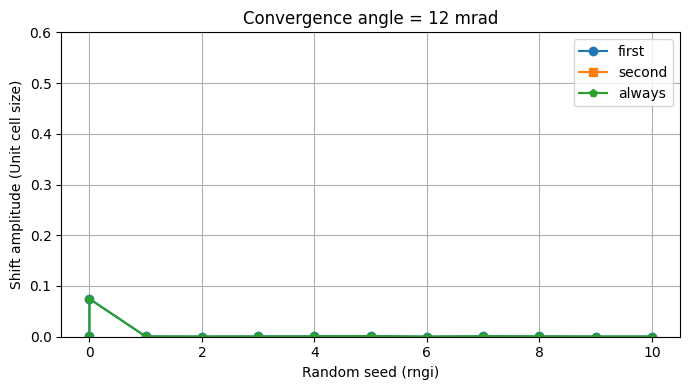

In [44]:
fig, ax = plt.subplots(figsize=(7,4))

for particle, marker in zip(["first", "second", 'always'], ["o", "s", 'p']):
    sub = dataset[dataset["particle"] == particle].sort_values("rngi")

    ax.plot(
        sub["rngi"],
        sub["shift_amplitude"]/(4*pixels_in_diff_pattern/256),
        marker=marker,
        label=particle,
    )

ax.set_xlabel("Random seed (rngi)")
ax.set_ylabel("Shift amplitude (Unit cell size)")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.grid(True)
ax.legend()
ax.set_ylim(0,0.6)
# ax.set_xlim(40,60)


plt.tight_layout()

save_path = os.path.join(
    results_dir,
    f"shift_amplitude_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}"
    f"_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}.png"
)
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to {save_path}")

plt.show()

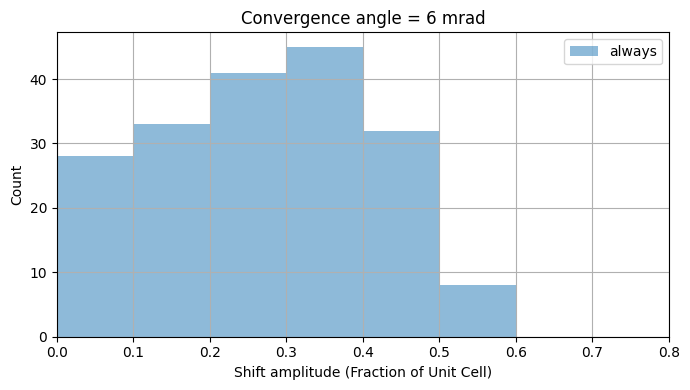

In [31]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.arange(0, 0.81, 0.1)  # 0.0, 0.1, ..., 0.6

# for particle in ["first", "second"]:

for particle in ["always"]:
    sub = dataset[dataset["particle"] == particle]

    values = sub["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=particle,
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Count")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.set_xlim(0, 0.8)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

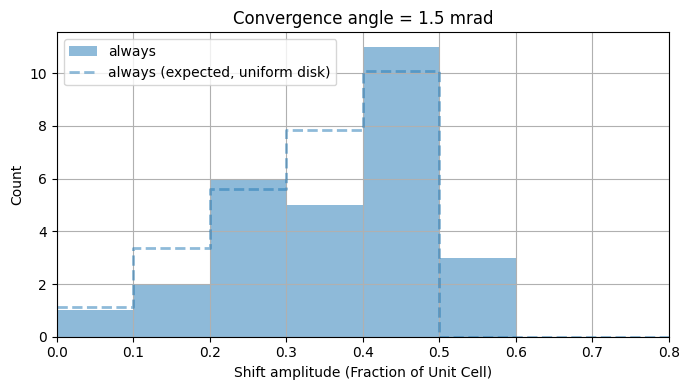

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.arange(0, 0.81, 0.1)  # 0.0, 0.1, ..., 0.8
bin_centers = 0.5 * (bins[:-1] + bins[1:])
r_max = 0.5

colors = {}  # to match hist and line colors per particle

# for particle in ["first", "second"]:

for particle in ["always"]:
    sub = dataset[dataset["particle"] == particle]

    values = sub["shift_amplitude"] / (4.18 * pixels_in_diff_pattern / 256)
    # values = values[values <= 0.5]   # <-- exclude points beyond r_max

    counts, _, patches = ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=particle,
    )
    colors[particle] = patches[0].get_facecolor()

    # --- expected counts under uniform-in-disk sampling, r ~ f(r) = 2r/r_max^2 ---
    N = len(values)
    edges_clipped = np.clip(bins, 0, r_max)
    cdf_at_edges = (edges_clipped ** 2) / r_max**2
    expected_counts = N * np.diff(cdf_at_edges)

    ax.step(
        bins,
        np.append(expected_counts, expected_counts[-1]),
        where="post",
        color=colors[particle],
        linestyle="--",
        linewidth=2,
        label=f"{particle} (expected, uniform disk)",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Count")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.set_xlim(0, 0.8)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

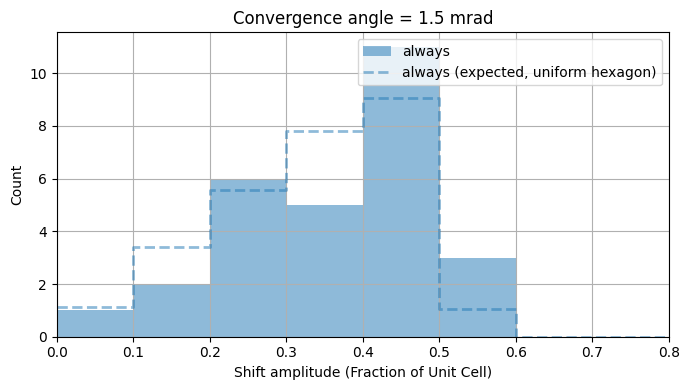

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

rng = np.random.default_rng(42)

def hexagon_vertices(R, rotation_deg=0):
    """Regular hexagon vertices with circumradius (vertex distance) R."""
    angles = np.deg2rad(np.arange(0, 360, 60) + rotation_deg)
    return np.column_stack([R * np.cos(angles), R * np.sin(angles)])

def sample_uniform_in_hexagon(R, N, rng, rotation_deg=0):
    """Rejection-sample N points uniformly inside a regular hexagon."""
    verts = hexagon_vertices(R, rotation_deg)
    path = Path(verts)
    pts = np.empty((0, 2))
    while pts.shape[0] < N:
        batch = rng.uniform(-R, R, size=(int(N * 1.5), 2))  # bounding square
        inside = path.contains_points(batch)
        pts = np.vstack([pts, batch[inside]])
    return pts[:N]

r_max = 0.55          # vertex distance
rotation_deg = 0      # set this to match your hexagon's orientation if needed
N_sim = 500_000       # large N for a smooth reference density

# Simulate once — reuse for all particles by rescaling
hex_pts = sample_uniform_in_hexagon(r_max, N_sim, rng, rotation_deg)
r_sim = np.linalg.norm(hex_pts, axis=1)

bins = np.arange(0, 0.81, 0.1)

fig, ax = plt.subplots(figsize=(7, 4))

for particle in ["always"]:
    sub = dataset[dataset["particle"] == particle]

    values = sub["shift_amplitude"] / (4.18 * pixels_in_diff_pattern / 256)
    N_particle = len(values)

    counts, _, patches = ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=particle,
    )
    color = patches[0].get_facecolor()

    # Expected counts: simulated hexagon density scaled to this particle's N
    sim_counts, _ = np.histogram(r_sim, bins=bins)
    expected_counts = sim_counts * (N_particle / N_sim)

    ax.step(
        bins,
        np.append(expected_counts, expected_counts[-1]),
        where="post",
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{particle} (expected, uniform hexagon)",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Count")
ax.set_title(f"Convergence angle = {convergence_angle} mrad")
ax.set_xlim(0, 0.8)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

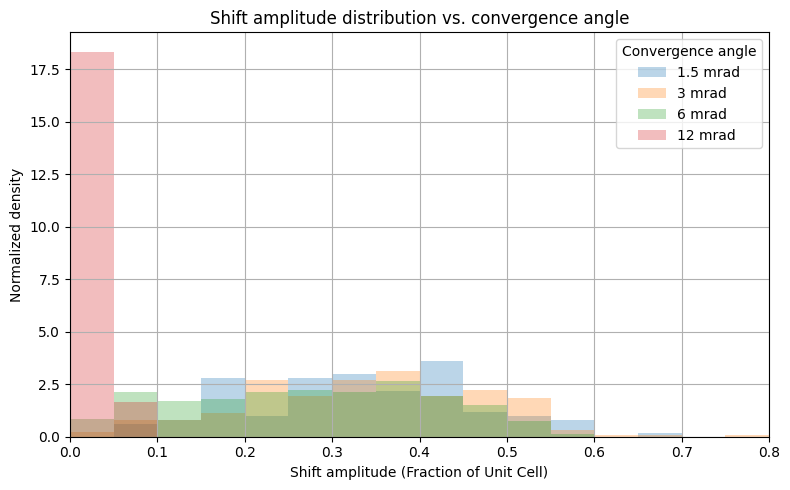

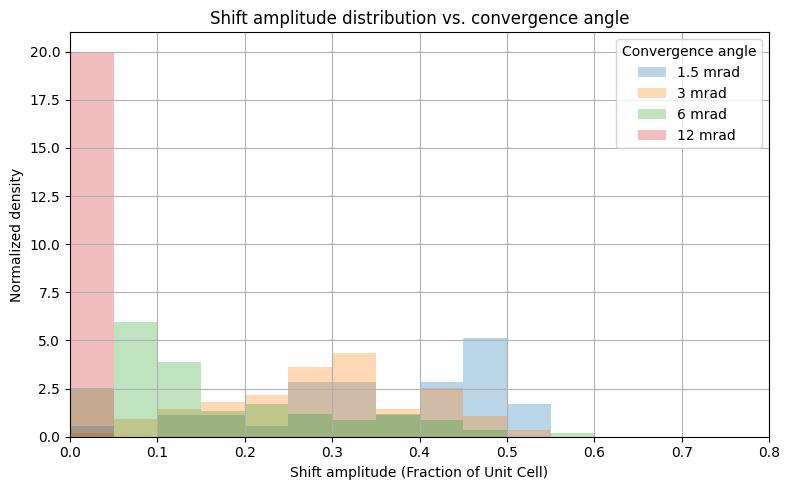

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings (everything except convergence_angle stays fixed)
# -----------------------------
gpts = 64
batch_size = 8
num_iters = 30
d = 10
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = False

convergence_angles = [1.5, 3, 6, 12]

def load_dataset(convergence_angle):
    dfs = []
    for particle in ["first", "second", "always"]:
        results_dir = (
            f"results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}"
            f"_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"
        )
        csv_path = os.path.join(
            results_dir,
            f"shifts_conv{convergence_angle}_batchsize{batch_size}"
            f"_iters{num_iters}_gpts{gpts}_{particle}.csv"
        )
        df = pd.read_csv(csv_path)
        df["particle"] = particle
        df["convergence_angle"] = convergence_angle

        if particle == "lower":
            correction_x, correction_y = 0, 0
        else:
            correction_x, correction_y = 0.205, 0.2175

        df["shift_amplitude"] = np.sqrt(
            (df["shift_x_0"] + correction_x) ** 2 + (df["shift_y_0"] + correction_y) ** 2
        )
        df["shift_angle"] = np.degrees(
            np.arctan2(df["shift_y_0"] + correction_y, df["shift_x_0"] + correction_x)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# -----------------------------
# Load all datasets
# -----------------------------
all_data_no_aC = {ca: load_dataset(ca) for ca in convergence_angles}


# -----------------------------
# Plot normalized histograms for all convergence angles
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "always"

for ca in convergence_angles:
    dataset_no_aC = all_data_no_aC[ca]
    sub = dataset_no_aC[dataset_no_aC["particle"] == particle_to_plot]

    values = sub["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    ax.hist(
        values,
        bins=bins,
        alpha=0.3,
        density=True,      # <-- normalizes so area under each histogram = 1
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Normalized density")
ax.set_title("Shift amplitude distribution vs. convergence angle")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True)

plt.tight_layout()
plt.show()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings (everything except convergence_angle stays fixed)
# -----------------------------
gpts = 64
batch_size = 8
num_iters = 30
d = 10
dose = 1e15
pixels_in_diff_pattern = 256
on_aC = True

convergence_angles = [1.5, 3, 6, 12]

def load_dataset(convergence_angle):
    dfs = []
    for particle in ["first", "second", "always"]:
        results_dir = (
            f"results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}"
            f"_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}"
        )
        csv_path = os.path.join(
            results_dir,
            f"shifts_conv{convergence_angle}_batchsize{batch_size}"
            f"_iters{num_iters}_gpts{gpts}_{particle}.csv"
        )
        df = pd.read_csv(csv_path)
        df["particle"] = particle
        df["convergence_angle"] = convergence_angle

        if particle == "lower":
            correction_x, correction_y = 0, 0
        else:
            correction_x, correction_y = 0.205, 0.2175

        df["shift_amplitude"] = np.sqrt(
            (df["shift_x_0"] + correction_x) ** 2 + (df["shift_y_0"] + correction_y) ** 2
        )
        df["shift_angle"] = np.degrees(
            np.arctan2(df["shift_y_0"] + correction_y, df["shift_x_0"] + correction_x)
        )
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


# -----------------------------
# Load all datasets
# -----------------------------
all_data_with_aC = {ca: load_dataset(ca) for ca in convergence_angles}


# -----------------------------
# Plot normalized histograms for all convergence angles
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "always"

for ca in convergence_angles:
    dataset_with_aC = all_data_with_aC[ca]
    sub_with_aC = dataset_with_aC[dataset_with_aC["particle"] == particle_to_plot]

    values_with_aC = sub_with_aC["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    ax.hist(
        values_with_aC,
        bins=bins,
        alpha=0.3,
        density=True,      # <-- normalizes so area under each histogram = 1
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Normalized density")
ax.set_title("Shift amplitude distribution vs. convergence angle")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True)

plt.tight_layout()
plt.show()

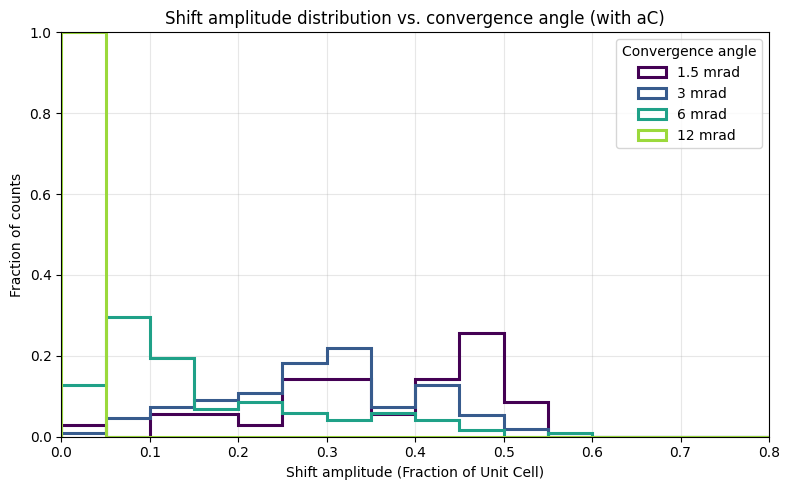

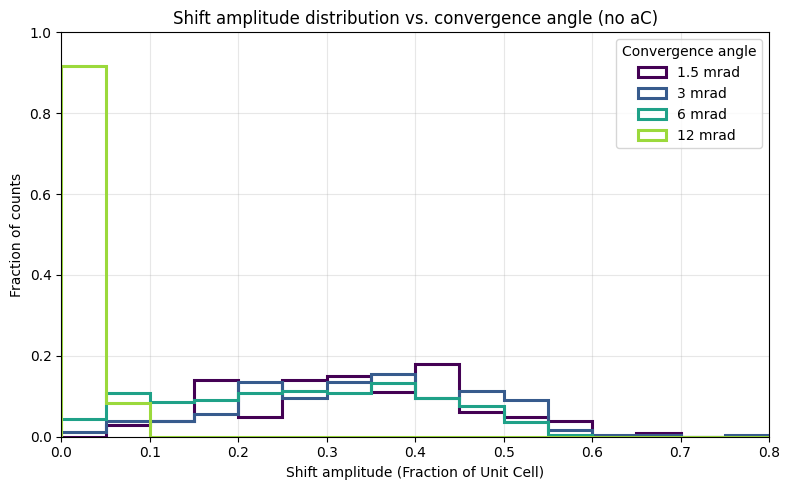

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "always"

colors = plt.cm.viridis(np.linspace(0, 0.85, len(convergence_angles)))

for ca, color in zip(convergence_angles, colors):
    dataset_with_aC = all_data_with_aC[ca]
    sub_with_aC = dataset_with_aC[dataset_with_aC["particle"] == particle_to_plot]
    values_with_aC = sub_with_aC["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    weights_with_aC = np.ones_like(values_with_aC) / len(values_with_aC)  # normalize to fraction of total

    ax.hist(
        values_with_aC,
        bins=bins,
        weights=weights_with_aC,
        histtype="step",
        linewidth=2.2,
        color=color,
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Fraction of counts")
ax.set_ylim(0, 1)
ax.set_title("Shift amplitude distribution vs. convergence angle (with aC)")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0, 0.81, 0.05)
particle_to_plot = "always"

colors = plt.cm.viridis(np.linspace(0, 0.85, len(convergence_angles)))

for ca, color in zip(convergence_angles, colors):
    dataset_no_aC = all_data_no_aC[ca]
    sub_no_aC = dataset_no_aC[dataset_no_aC["particle"] == particle_to_plot]
    values_no_aC = sub_no_aC["shift_amplitude"] / (4.2 * pixels_in_diff_pattern / 256)

    weights_no_aC = np.ones_like(values_no_aC) / len(values_no_aC)  # normalize to fraction of total

    ax.hist(
        values_no_aC,
        bins=bins,
        weights=weights_no_aC,
        histtype="step",
        linewidth=2.2,
        color=color,
        label=f"{ca} mrad",
    )

ax.set_xlabel("Shift amplitude (Fraction of Unit Cell)")
ax.set_ylabel("Fraction of counts")
ax.set_ylim(0, 1)
ax.set_title("Shift amplitude distribution vs. convergence angle (no aC)")
ax.set_xlim(0, 0.8)
ax.legend(title="Convergence angle")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()